Testes de single qubit para estudo

Para classificar o seu dataset sintético (como o do círculo) usando o código do seu arquivo single_qubit.py, você precisará integrar as funções do circuito quântico com um otimizador clássico do scipy.optimize.

O fluxo consiste em inicializar os parâmetros quânticos, calcular os estados ideais de referência para cada classe, e minimizar a função de custo (single_cost_function) usando os seus dados de treino.

Entendendo os Componentes do seu Código:

representatives(n_classes, qubits_lab): Como o círculo possui duas classes (0 para fora e 1 para dentro), você usará n_classes=2 e qubits_lab=1.
Essa função vai gerar os estados ideais (alvos) na Esfera de Bloch: o vetor $[1, 0]^T$ ($|0\rangle$) para a classe 0 e $[0, 1]^T$ ($|1\rangle$) para a classe 1.

single_qubit_circuit: Repare que o seu circuito quântico realiza rotações baseadas em phi = theta[i] + w[i]*x. Como o seu dataset do círculo possui duas dimensões ($x \in \mathbb{R}^2$), o seu vetor de entrada x possui tamanho 2. Para que a multiplicação vetorial funcione corretamente no loop do seu código, os pesos $w[i]$ e parâmetros $\theta[i]$ precisam estar alinhados com a dimensionalidade dos dados de entrada.

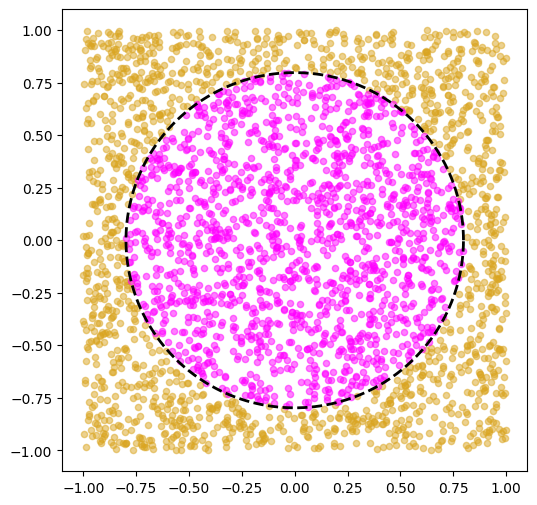

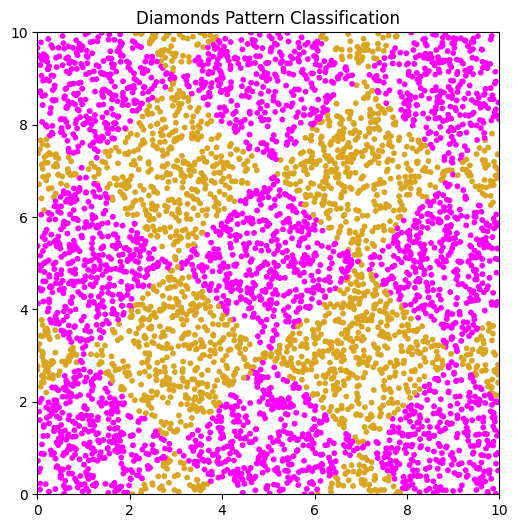

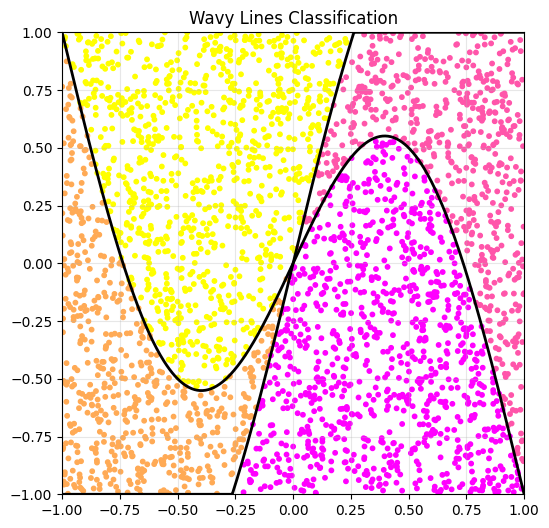

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from datasets import circle, plot_circle

In [2]:
data, (centers, radii) = circle(samples=3000, random_seed=42)

In [3]:
for i in range(3):
    print(f"Amostra {i}: {data[i][0]} → Label: {data[i][1]}")

Amostra 0: [-0.25091976  0.90142861  0.        ] → Label: 0
Amostra 1: [0.46398788 0.19731697 0.        ] → Label: 1
Amostra 2: [-0.68796272 -0.68801096  0.        ] → Label: 0


In [4]:
#Train/test split
data, (centers, radii) = circle(samples=5000, random_seed=42)
x = np.array([i[0] for i in data])
y = np.array([i[1] for i in data])

x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y) #stratify allows to have a balance amount of labels in each split

Como a equação define um vetor de 3 dimensões $\vec{\phi}(\vec{x}) = (\phi_1(\vec{x}), \phi_2(\vec{x}), \phi_3(\vec{x}))$, isso significa que para cada camada do seu circuito, tanto os parâmetros bias $\vec{\theta}$ quanto os pesos $\vec{w}$ e os dados de entrada $\vec{x}$ precisam ter exatamente o mesmo tamanho: 3 dimensões.

Como o seu dataset do círculo (ou as componentes principais do Iris) possui apenas 2 dimensões ($x_0, x_1$), o broadcasting falha porque o vetor $\vec{x}$ original não tem a terceira componente para multiplicar com a terceira componente de $\vec{w}$.Para corrigir isso mantendo a lógica exata de produto Hadamard ($\vec{w} \circ \vec{x}$) sugerida pelo artigo, a estratégia ideal é realizar o Padding (preenchimento) dos seus dados clássicos antes de enviá-los ao otimizador, estendendo $\vec{x}$ para 3 dimensões de forma neutra.

In [5]:
# Aplica o Padding para adicionar uma 3ª dimensão preenchida com zeros
# (0, 0) significa não adicionar linhas no início/fim
# (0, 1) significa adicionar 1 coluna extra no final do array
X_train_padded = np.pad(x_train, ((0, 0), (0, 1)), mode='constant', constant_values=0)
X_test_padded = np.pad(x_test, ((0, 0), (0, 1)), mode='constant', constant_values=0)

# Agora os seus dados têm formato (N_amostras, 3), casando com w e theta!

In [5]:
np.shape(X_train_padded), np.shape(X_test_padded)

NameError: name 'X_train_padded' is not defined

In [6]:
import numpy as np
from scipy.optimize import minimize
from sklearn.metrics import accuracy_score
from single_qubit import (single_qubit_params, pack_params, representatives,
                          single_cost_function, single_unpack_params, single_qubit_predict)

In [7]:
# 1. Configurações do Modelo Quântico
n_layers = 1    # Número de camadas do circuito quântico (ansatz)
n_classes = 2     # Classificação binária (dentro ou fora do círculo)
qubits_lab = 1    # Estamos usando um único qubit

In [8]:
# 2. Gerar os estados quânticos de referência (alvos para cada classe)
reprs = representatives(n_classes, qubits_lab)

In [9]:
# 3. Inicializar os parâmetros quânticos aleatoriamente (theta, w, alpha)
# O formato de theta e w gerado pela sua função lida nativamente com arrays n_layers x 3
theta_init, w_init, alpha_init = single_qubit_params(n_layers, n_classes)

In [10]:
# Empacotar os parâmetros em um único vetor unidimensional para o scipy.minimize
initial_params = pack_params(theta_init, w_init, alpha_init)

print("Iniciando o treinamento do Single Qubit Classifier...")

Iniciando o treinamento do Single Qubit Classifier...


In [11]:
# 4. Otimização Clássica (Treinamento)
# Passamos a função de custo, os parâmetros iniciais e os dados de treino como argumentos extras (args)
result = minimize(
    fun=single_cost_function,
    x0=initial_params,
    args=(x_train, y_train, n_layers, n_classes, reprs),
    method='L-BFGS-B',  # Método baseado em regiões de confiança, excelente para otimização sem derivadas (Gradient-Free)
    options={'maxiter': 200}  # Limite de iterações para testar o comportamento
)

In [14]:
# 5. Desempacotar os parâmetros ótimos encontrados pelo otimizador
optimal_params = result.x
theta_opt, w_opt, alpha_opt = single_unpack_params(optimal_params, n_layers, n_classes)

print("\nOtimização concluída!")
print(f"Sucesso: {result.success}")
print(f"Valor final da função de custo: {result.fun}")


Otimização concluída!
Sucesso: True
Valor final da função de custo: 1212.1826367686645


In [15]:
# 6. Avaliação do Modelo (Predição)
# Usando os parâmetros otimizados para prever as classes no conjunto de teste
y_pred_train = single_qubit_predict(x_train, n_layers, n_classes, theta_opt, w_opt, reprs)
y_pred_test = single_qubit_predict(x_test, n_layers, n_classes, theta_opt, w_opt, reprs)

# Calcular a acurácia
acc_train = accuracy_score(y_train, y_pred_train)
acc_test = accuracy_score(y_test, y_pred_test)

print(f"\nAcurácia no Treino: {acc_train * 100:.2f}%")
print(f"Acurácia no Teste: {acc_test * 100:.2f}%")


Acurácia no Treino: 73.20%
Acurácia no Teste: 73.10%


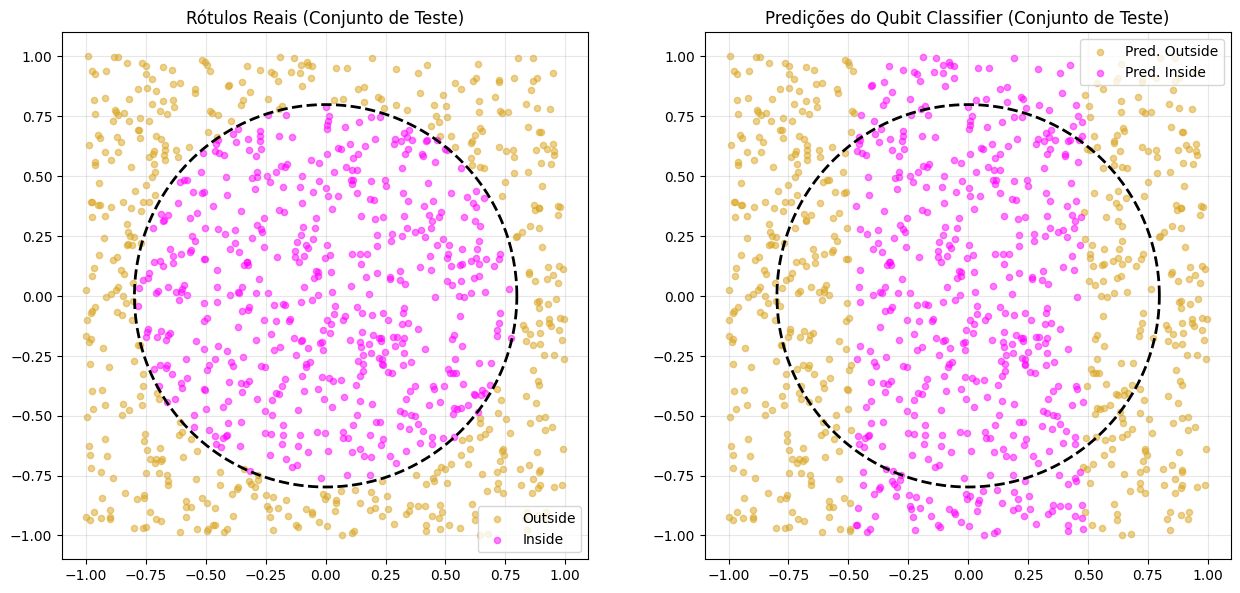

In [19]:
#Abordagem 1: Plotar Comparativo (Lado a Lado)
#eaproveitar quase toda a estrutura da sua função plot_circle. A principal diferença é que, em vez de passar as etiquetas reais (y), 
# você passará as predições geradas pela função single_qubit_predict do seu modelo.

def plot_quantum_predictions(X_data, y_real, y_pred, centers, radii, title_suffix=""):
    """
    X_data: Pode ser o X_test original (N, 2) ou o X_test_padded (N, 3).
            O scatter usará apenas as duas primeiras colunas clássicas.
    """
    center = centers[0]
    radius = radii[0]
    theta_vals = np.linspace(0, 2*np.pi, 200)
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 6))
    
    # --- GRÁFICO 1: GABARITO REAL ---
    ax1.scatter(X_data[y_real == 0, 0], X_data[y_real == 0, 1], c='goldenrod', alpha=0.5, s=20, label='Outside')
    ax1.scatter(X_data[y_real == 1, 0], X_data[y_real == 1, 1], c='fuchsia', alpha=0.5, s=20, label='Inside')
    ax1.plot(center[0] + radius * np.cos(theta_vals), center[1] + radius * np.sin(theta_vals), 'k--', linewidth=2)
    ax1.set_title(f"Rótulos Reais {title_suffix}")
    ax1.set_aspect('equal')
    ax1.legend()
    ax1.grid(alpha=0.3)
    
    # --- GRÁFICO 2: PREDIÇÃO DO QUBIT ---
    ax2.scatter(X_data[y_pred == 0, 0], X_data[y_pred == 0, 1], c='goldenrod', alpha=0.5, s=20, label='Pred. Outside')
    ax2.scatter(X_data[y_pred == 1, 0], X_data[y_pred == 1, 1], c='fuchsia', alpha=0.5, s=20, label='Pred. Inside')
    ax2.plot(center[0] + radius * np.cos(theta_vals), center[1] + radius * np.sin(theta_vals), 'k--', linewidth=2)
    ax2.set_title(f"Predições do Qubit Classifier {title_suffix}")
    ax2.set_aspect('equal')
    ax2.legend()
    ax2.grid(alpha=0.3)
    
    plt.tight_layout()
    plt.show()

# --- COMO CHAMAR DEPOIS DO TREINAMENTO ---
# Gerando as predições com os parâmetros ótimos encontrados
y_pred_test = single_qubit_predict(X_test_padded, n_layers, n_classes, theta_opt, w_opt, reprs)

# Plotando o resultado para o conjunto de teste
plot_quantum_predictions(X_test_padded, y_test, y_pred_test, centers, radii, title_suffix="(Conjunto de Teste)")

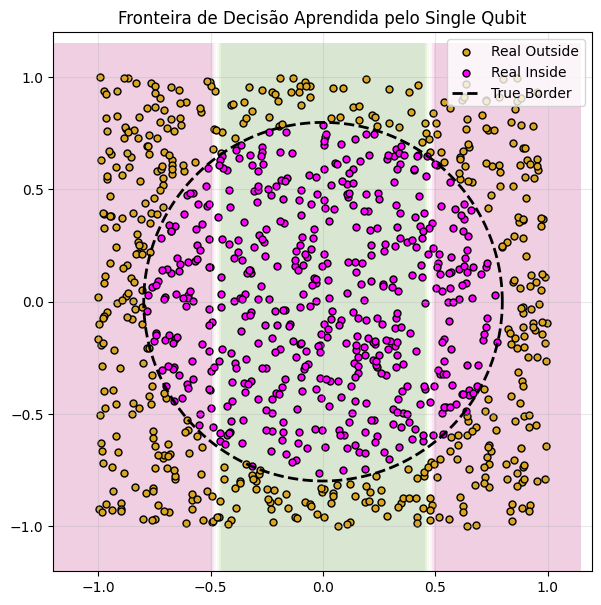

In [17]:
#Abordagem 2: Plotar a Fronteira de Decisão (Decision Boundary)
#Como o classificador quântico mapeia os dados clássicos para a Esfera de Bloch e tenta separá-los usando o equador, é fascinante ver como essa fronteira de decisão "quântica" se projeta de volta no plano bidimensional clássico.
#Para fazer isso, geramos uma grade densa de pontos (meshgrid) sobre o espaço do gráfico e pedimos para o qubit classificar cada ponto.

def plot_quantum_decision_boundary(X_data, y_real, n_layers, n_classes, theta_opt, w_opt, reprs, centers, radii):
    # 1. Definir os limites do gráfico com base nos seus dados
    x_min, x_max = X_data[:, 0].min() - 0.2, X_data[:, 0].max() + 0.2
    y_min, y_max = X_data[:, 1].min() - 0.2, X_data[:, 1].max() + 0.2
    
    # 2. Criar a grade de pontos (mesh)
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.05),
                         np.arange(y_min, y_max, 0.05))
    
    # Achatar a grade para passar pelo modelo
    grid_points = np.c_[xx.ravel(), yy.ravel()]
    
    # Aplicar o mesmo padding (3ª dimensão com zeros) necessário para o circuito quântico
    grid_points_padded = np.pad(grid_points, ((0, 0), (0, 1)), mode='constant', constant_values=0)
    
    # 3. Predizer a classe quântica para cada ponto da grade
    Z = single_qubit_predict(grid_points_padded, n_layers, n_classes, theta_opt, w_opt, reprs)
    Z = Z.reshape(xx.shape)
    
    # 4. Plotar a superfície de decisão encontrada pelo Qubit
    plt.figure(figsize=(7, 7))
    plt.contourf(xx, yy, Z, alpha=0.2, cmap='PiYG') # Pinta as regiões de decisão ao fundo
    
    # 5. Plotar os pontos reais de teste por cima para comparação
    plt.scatter(X_data[y_real == 0, 0], X_data[y_real == 0, 1], c='goldenrod', edgecolor='k', s=25, label='Real Outside')
    plt.scatter(X_data[y_real == 1, 0], X_data[y_real == 1, 1], c='fuchsia', edgecolor='k', s=25, label='Real Inside')
    
    # Desenhar a borda analítica teórica do círculo clássico
    center = centers[0]
    radius = radii[0]
    theta_vals = np.linspace(0, 2*np.pi, 200)
    plt.plot(center[0] + radius * np.cos(theta_vals), center[1] + radius * np.sin(theta_vals), 'k--', linewidth=2, label='True Border')
    
    plt.title("Fronteira de Decisão Aprendida pelo Single Qubit")
    plt.xlim(x_min, x_max)
    plt.ylim(y_min, y_max)
    plt.gca().set_aspect('equal')
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

# --- COMO CHAMAR ---
plot_quantum_decision_boundary(x_test, y_test, n_layers, n_classes, theta_opt, w_opt, reprs, centers, radii)

## TODO O CODIGO QUE VAI RODAR AQUI Ó

In [ ]:
# ============================================================
# CLASSIFICADOR GENERALIZADO
# ============================================================

class SingleQubitClassifier:
    """
    Classificador quântico de um qubit para datasets sintéticos
    
    Parâmetros:
        dataset_type: 'circle', 'diamond' ou 'wavy_lines'
        n_layers: número de camadas no circuito: rodar 
        n_samples: número de amostras do dataset
        test_size: proporção do teste
        random_state: seed para reprodutibilidade
    """
    
    def __init__(self, dataset_type='circle', n_layers=2, n_samples=1000, 
                 test_size=0.2, random_state=42):
        
        if dataset_type not in ['circle', 'diamond', 'wavy_lines']:
            raise ValueError("dataset_type deve ser 'circle', 'diamond' ou 'wavy_lines'")
        
        self.dataset_type = dataset_type
        self.n_layers = n_layers
        self.n_samples = n_samples
        self.test_size = test_size
        self.random_state = random_state
        
        # Carregar dataset
        self._load_dataset()
        
        # Preparar dados
        self._prepare_data()
        
        # Configurar número de classes
        self.n_classes = len(np.unique(self.y_full))
        self.reprs = representatives(self.n_classes)
        
        # Parâmetros quânticos
        self.theta_opt = None
        self.w_opt = None
        self.alpha_opt = None
        
        print(f"\n{'='*60}")
        print(f"Single-Qubit Classifier - {self.dataset_type.upper()}")
        print(f"{'='*60}")
        print(f"Dataset: {self.dataset_type}")
        print(f"Número de classes: {self.n_classes}")
        print(f"Tamanho treino: {len(self.X_train)}")
        print(f"Tamanho teste: {len(self.X_test)}")
        print(f"Número de camadas: {self.n_layers}")
        print(f"{'='*60}\n")
    
    def _load_dataset(self):
        """Carrega o dataset especificado"""
        
        if self.dataset_type == 'circle':
            data, (centers, radii) = circle(samples=self.n_samples, random_seed=self.random_state)
            self.X_full = np.array([d[0] for d in data])
            self.y_full = np.array([d[1] for d in data])
            self.metadata = {'centers': centers, 'radii': radii}
            
        elif self.dataset_type == 'diamond':
            x, y, logic = diamond(samples=self.n_samples, limit=10, scale=4.0, 
                                 random_seed=self.random_state)
            self.X_full = np.column_stack([x, y])
            self.y_full = logic
            self.metadata = {'limit': 10, 'scale': 4.0}
            
        elif self.dataset_type == 'wavy_lines':
            data, freq = wavy_lines(samples=self.n_samples, freq=1)
            self.X_full = np.array([d[0] for d in data])
            self.y_full = np.array([d[1] for d in data])
            self.metadata = {'freq': freq}
    
    def _prepare_data(self):
        """Divide e normaliza os dados"""
        
        # Dividir em treino e teste
        indices = np.arange(len(self.X_full))
        np.random.seed(self.random_state)
        np.random.shuffle(indices)
        
        split_idx = int((1 - self.test_size) * len(indices))
        train_indices = indices[:split_idx]
        test_indices = indices[split_idx:]
        
        self.X_train = self.X_full[train_indices]
        self.y_train = self.y_full[train_indices]
        self.X_test = self.X_full[test_indices]
        self.y_test = self.y_full[test_indices]
        
        # Garantir tipos corretos
        self.X_train = self.X_train.astype(float)
        self.X_test = self.X_test.astype(float)
        self.y_train = self.y_train.astype(int)
        self.y_test = self.y_test.astype(int)
    
    def train(self, method='BFGS', verbose=True):
        """Treina o classificador"""
        
        print(f"Treinando com método {method}...\n")
        
        # Inicializar parâmetros
        theta_init, w_init, alpha_init = single_qubit_params(self.n_layers, self.n_classes)
        params_init = pack_params(theta_init, w_init, alpha_init)
        
        # Função de custo para otimizador
        def cost_wrapper(params):
            return single_cost_function(params, self.X_train, self.y_train, 
                                       self.n_layers, self.n_classes, self.reprs)
        
        # Otimizar
        result = minimize(cost_wrapper, params_init, method=method, 
                         options={'disp': verbose})
        
        # Desempacotar resultado
        self.theta_opt, self.w_opt, self.alpha_opt = single_unpack_params(
            result.x, self.n_layers, self.n_classes
        )
        
        print(f"\nTreinamento concluído!")
        print(f"Custo final: {result.fun:.6f}")
        print(f"Sucesso: {result.success}\n")
        
        return result
    
    def predict(self, X):
        """Faz predições"""
        if self.theta_opt is None:
            raise ValueError("Modelo não foi treinado. Execute .train() primeiro.")
        
        return single_qubit_predict(X, self.n_layers, self.n_classes, 
                                   self.theta_opt, self.w_opt, self.reprs)
    
    def evaluate(self):
        """Avalia o desempenho"""
        y_pred_train = self.predict(self.X_train)
        y_pred_test = self.predict(self.X_test)
        
        train_acc = np.mean(y_pred_train == self.y_train)
        test_acc = np.mean(y_pred_test == self.y_test)
        
        print(f"{'='*60}")
        print(f"RESULTADOS DO TESTE")
        print(f"{'='*60}")
        print(f"Acurácia Treino: {train_acc*100:.2f}%")
        print(f"Acurácia Teste:  {test_acc*100:.2f}%")
        print(f"{'='*60}\n")
        
        return train_acc, test_acc
    
    def plot_results(self):
        """Plota os resultados em dois gráficos"""
        
        y_pred_train = self.predict(self.X_train)
        y_pred_test = self.predict(self.X_test)
        
        fig, axes = plt.subplots(1, 2, figsize=(14, 6))
        
        # ===== GRÁFICO 1: DATASET ORIGINAL =====
        ax = axes[0]
        
        if self.dataset_type == 'circle':
            centers = self.metadata['centers']
            radii = self.metadata['radii']
            center = centers[0]
            radius = radii[0]
            
            ax.scatter(self.X_test[self.y_test == 0, 0], 
                      self.X_test[self.y_test == 0, 1], 
                      c='goldenrod', alpha=0.6, s=30, label='Verdadeiro: Fora')
            ax.scatter(self.X_test[self.y_test == 1, 0], 
                      self.X_test[self.y_test == 1, 1], 
                      c='fuchsia', alpha=0.6, s=30, label='Verdadeiro: Dentro')
            
            theta_vals = np.linspace(0, 2*np.pi, 200)
            ax.plot(center[0] + radius*np.cos(theta_vals), 
                   center[1] + radius*np.sin(theta_vals), 
                   'k--', linewidth=2, label='Fronteira Real')
            
        elif self.dataset_type == 'diamond':
            colors = np.where(self.y_test == 0, 'goldenrod', 'fuchsia')
            ax.scatter(self.X_test[:, 0], self.X_test[:, 1], c=colors, s=30, alpha=0.6)
            
        elif self.dataset_type == 'wavy_lines':
            ax.scatter(self.X_test[:, 0], self.X_test[:, 1], c=self.y_test, 
                      cmap='spring', s=30, alpha=0.6)
        
        ax.set_xlim(self.X_test[:, 0].min()-0.2, self.X_test[:, 0].max()+0.2)
        ax.set_ylim(self.X_test[:, 1].min()-0.2, self.X_test[:, 1].max()+0.2)
        ax.set_aspect('equal')
        ax.grid(alpha=0.3)
        ax.set_xlabel('$x_0$', fontsize=12)
        ax.set_ylabel('$x_1$', fontsize=12)
        ax.set_title(f'Dataset Original - {self.dataset_type}', fontsize=13, fontweight='bold')
        ax.legend()
        
        # ===== GRÁFICO 2: PREDIÇÕES DO QUBIT =====
        ax = axes[1]
        
        # Pontos classificados corretamente
        correct = y_pred_test == self.y_test
        
        if self.dataset_type == 'circle':
            ax.scatter(self.X_test[correct, 0], self.X_test[correct, 1], 
                      c='green', alpha=0.6, s=30, label='✓ Correto', marker='o')
            ax.scatter(self.X_test[~correct, 0], self.X_test[~correct, 1], 
                      c='red', alpha=0.6, s=50, label='✗ Erro', marker='X')
            
            centers = self.metadata['centers']
            radii = self.metadata['radii']
            center = centers[0]
            radius = radii[0]
            theta_vals = np.linspace(0, 2*np.pi, 200)
            ax.plot(center[0] + radius*np.cos(theta_vals), 
                   center[1] + radius*np.sin(theta_vals), 
                   'k--', linewidth=2, label='Fronteira Real')
            
        elif self.dataset_type == 'diamond' or self.dataset_type == 'wavy_lines':
            colors_correct = np.where(correct, 'green', 'red')
            markers = np.where(correct, 'o', 'X')
            
            for i in range(len(self.X_test)):
                ax.scatter(self.X_test[i, 0], self.X_test[i, 1], 
                          c=colors_correct[i], s=50, alpha=0.6, marker=markers[i])
        
        ax.set_xlim(self.X_test[:, 0].min()-0.2, self.X_test[:, 0].max()+0.2)
        ax.set_ylim(self.X_test[:, 1].min()-0.2, self.X_test[:, 1].max()+0.2)
        ax.set_aspect('equal')
        ax.grid(alpha=0.3)
        ax.set_xlabel('$x_0$', fontsize=12)
        ax.set_ylabel('$x_1$', fontsize=12)
        
        accuracy = np.mean(correct) * 100
        ax.set_title(f'Predições Quânticas - Acurácia: {accuracy:.1f}%', 
                    fontsize=13, fontweight='bold')
        ax.legend()
        
        plt.tight_layout()
        plt.show()

# ============================================================
# EXEMPLO DE USO
# ============================================================

if __name__ == "__main__":
    
    # ===== TESTE 1: CÍRCULO =====
    print("\n" + "="*60)
    print("TESTE 1: CLASSIFICAÇÃO DO CÍRCULO")
    print("="*60)
    
    classifier_circle = SingleQubitClassifier(
        dataset_type='circle',
        n_layers=2,
        n_samples=500,
        test_size=0.2,
        random_state=42
    )
    
    classifier_circle.train(method='BFGS', verbose=False)
    classifier_circle.evaluate()
    classifier_circle.plot_results()
    
    # ===== TESTE 2: DIAMOND =====
    print("\n" + "="*60)
    print("TESTE 2: CLASSIFICAÇÃO DO DIAMOND")
    print("="*60)
    
    classifier_diamond = SingleQubitClassifier(
        dataset_type='diamond',
        n_layers=2,
        n_samples=1000,
        test_size=0.2,
        random_state=42
    )
    
    classifier_diamond.train(method='BFGS', verbose=False)
    classifier_diamond.evaluate()
    classifier_diamond.plot_results()
    
    # ===== TESTE 3: WAVY LINES =====
    print("\n" + "="*60)
    print("TESTE 3: CLASSIFICAÇÃO WAVY LINES")
    print("="*60)
    
    classifier_wavy = SingleQubitClassifier(
        dataset_type='wavy_lines',
        n_layers=3,
        n_samples=1000,
        test_size=0.2,
        random_state=42
    )
    
    classifier_wavy.train(method='BFGS', verbose=False)
    classifier_wavy.evaluate()
    classifier_wavy.plot_results()